**Chương 8 – Giảm chiều dữ liệu**

_Cuốn sổ tay này chứa tất cả mã mẫu và giải pháp cho các bài tập trong chương 8._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/08_dimensionality_reduction.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Thiết lập

Dự án này yêu cầu Python 3.7 trở lên.

In [ ]:
import sys

assert sys.version_info >= (3, 7)

Nó cũng yêu cầu Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Như chúng ta đã thực hiện trong các chương trước, hãy định nghĩa các kích thước phông chữ mặc định để làm cho các hình ảnh trở nên đẹp hơn:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Và hãy tạo thư mục images/dim_reduction (nếu nó chưa tồn tại), và định nghĩa hàm save_fig() được sử dụng trong toàn bộ sổ tay này để lưu các hình ảnh với độ phân giải cao cho cuốn sách:

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "dim_reduction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# PCA

Chương này bắt đầu bằng một số hình ảnh để giải thích các khái niệm về PCA và N học Đường cong. Dưới đây là mã để tạo ra những hình ảnh này. Bạn có thể bỏ qua trực tiếp phần Thành phần chính bên dưới nếu bạn muốn.

Hãy tạo ra một tập dữ liệu 3D nhỏ. Nó có hình oval, xoay quanh không gian 3D, với các điểm phân bố không đều, và có khá nhiều tiếng ồn:

In [ ]:
# extra code

import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

Vẽ tập dữ liệu 3D, với mặt phẳng chiếu.

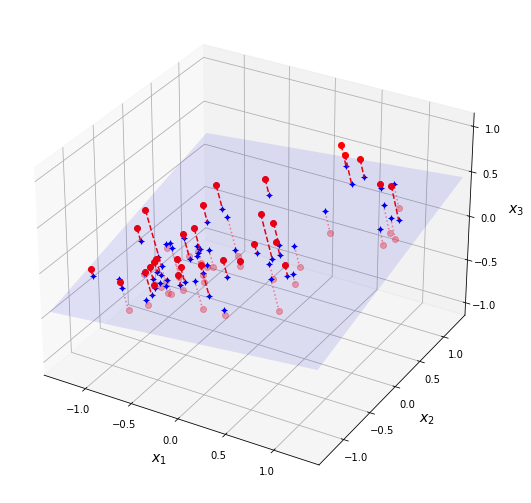

In [ ]:
# extra code – this cell generates and saves Figure 8–2

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)  # dataset reduced to 2D
X3D_inv = pca.inverse_transform(X2D)  # 3D position of the projected samples
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

axes = [-1.4, 1.4, -1.4, 1.4, -1.1, 1.1]
x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 10),
                     np.linspace(axes[2], axes[3], 10))
w1, w2 = np.linalg.solve(Vt[:2, :2], Vt[:2, 2])  # projection plane coefs
z = w1 * (x1 - pca.mean_[0]) + w2 * (x2 - pca.mean_[1]) - pca.mean_[2]  # plane
X3D_above = X[X[:, 2] >= X3D_inv[:, 2]]  # samples above plane
X3D_below = X[X[:, 2] < X3D_inv[:, 2]]  # samples below plane

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

# plot samples and projection lines below plane first
ax.plot(X3D_below[:, 0], X3D_below[:, 1], X3D_below[:, 2], "ro", alpha=0.3)
for i in range(m):
    if X[i, 2] < X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], ":", color="#F88")

ax.plot_surface(x1, x2, z, alpha=0.1, color="b")  # projection plane
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b+")  # projected samples
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b.")

# now plot projection lines and samples above plane
for i in range(m):
    if X[i, 2] >= X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], "r--")

ax.plot(X3D_above[:, 0], X3D_above[:, 1], X3D_above[:, 2], "ro")

def set_xyz_axes(ax, axes):
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_xlabel("$x_1$", labelpad=8, rotation=0)
    ax.set_ylabel("$x_2$", labelpad=8, rotation=0)
    ax.set_zlabel("$x_3$", labelpad=8, rotation=0)
    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])

set_xyz_axes(ax, axes)
ax.set_zticks([-1, -0.5, 0, 0.5, 1])

save_fig("dataset_3d_plot", tight_layout=False)
plt.show()

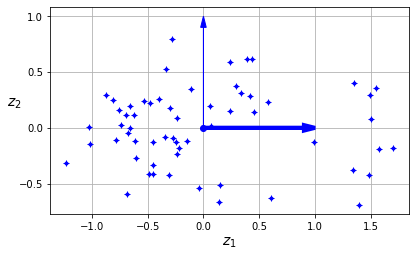

In [ ]:
# extra code – this cell generates and saves Figure 8–3

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect='equal')
ax.plot(X2D[:, 0], X2D[:, 1], "b+")
ax.plot(X2D[:, 0], X2D[:, 1], "b.")
ax.plot([0], [0], "bo")
ax.arrow(0, 0, 1, 0, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=4)
ax.arrow(0, 0, 0, 1, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=1)
ax.set_xlabel("$z_1$")
ax.set_yticks([-0.5, 0, 0.5, 1])
ax.set_ylabel("$z_2$", rotation=0)
ax.set_axisbelow(True)
ax.grid(True)
save_fig("dataset_2d_plot")

In [ ]:
from sklearn.datasets import make_swiss_roll

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

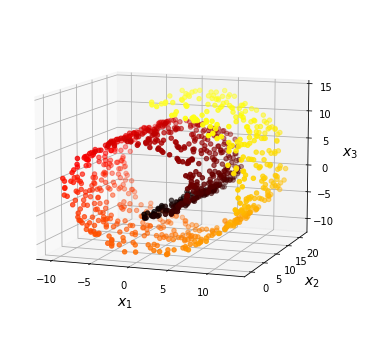

In [ ]:
# extra code – this cell generates and saves Figure 8–4

from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=darker_hot)
ax.view_init(10, -70)
set_xyz_axes(ax, axes)
save_fig("swiss_roll_plot")
plt.show()

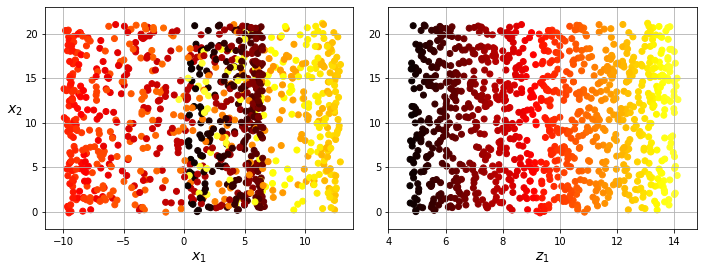

In [ ]:
# extra code – this cell generates and saves plots for Figure 8–5

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.scatter(X_swiss[:, 0], X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis(axes[:4])
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", labelpad=10, rotation=0)
plt.grid(True)

plt.subplot(122)
plt.scatter(t, X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis([4, 14.8, axes[2], axes[3]])
plt.xlabel("$z_1$")
plt.grid(True)

save_fig("squished_swiss_roll_plot")
plt.show()

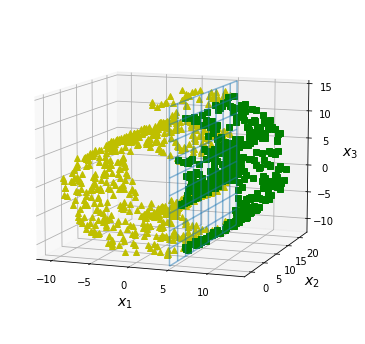

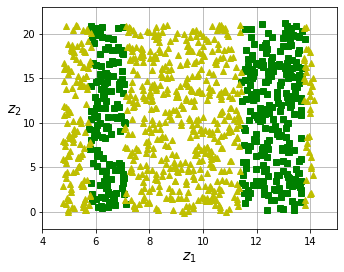

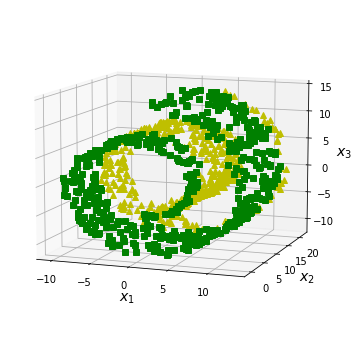

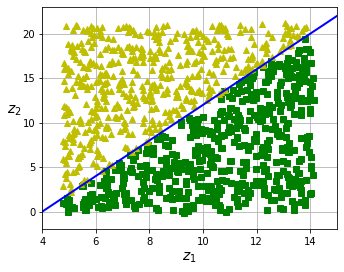

In [ ]:
# extra code – this cell generates and saves plots for Figure 8–6

axes = [-11.5, 14, -2, 23, -12, 15]
x2s = np.linspace(axes[2], axes[3], 10)
x3s = np.linspace(axes[4], axes[5], 10)
x2, x3 = np.meshgrid(x2s, x3s)

positive_class = X_swiss[:, 0] > 5
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot_wireframe(5, x2, x3, alpha=0.5)
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
set_xyz_axes(ax, axes)
save_fig("manifold_decision_boundary_plot1")
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
save_fig("manifold_decision_boundary_plot2")
plt.show()

positive_class = 2 * (t[:] - 4) > X_swiss[:, 1]
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel("$x_1$", rotation=0)
ax.set_ylabel("$x_2$", rotation=0)
ax.set_zlabel("$x_3$", rotation=0)
ax.set_xlim(axes[0:2])
ax.set_ylim(axes[2:4])
ax.set_zlim(axes[4:6])
save_fig("manifold_decision_boundary_plot3")
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.plot([4, 15], [0, 22], "b-", linewidth=2)
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
save_fig("manifold_decision_boundary_plot4")
plt.show()

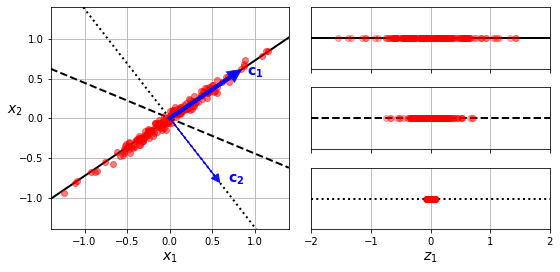

In [ ]:
# extra code – this cell generates and saves Figure 8–7

angle = np.pi / 5
stretch = 5
m = 200

np.random.seed(3)
X_line = np.random.randn(m, 2) / 10
X_line = X_line @ np.array([[stretch, 0], [0, 1]])  # stretch
X_line = X_line @ [[np.cos(angle), np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]]  # rotate

u1 = np.array([np.cos(angle), np.sin(angle)])
u2 = np.array([np.cos(angle - 2 * np.pi / 6), np.sin(angle - 2 * np.pi / 6)])
u3 = np.array([np.cos(angle - np.pi / 2), np.sin(angle - np.pi / 2)])

X_proj1 = X_line @ u1.reshape(-1, 1)
X_proj2 = X_line @ u2.reshape(-1, 1)
X_proj3 = X_line @ u3.reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.subplot2grid((3, 2), (0, 0), rowspan=3)
plt.plot([-1.4, 1.4], [-1.4 * u1[1] / u1[0], 1.4 * u1[1] / u1[0]], "k-",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u2[1] / u2[0], 1.4 * u2[1] / u2[0]], "k--",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u3[1] / u3[0], 1.4 * u3[1] / u3[0]], "k:",
         linewidth=2)
plt.plot(X_line[:, 0], X_line[:, 1], "ro", alpha=0.5)
plt.arrow(0, 0, u1[0], u1[1], head_width=0.1, linewidth=4, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.arrow(0, 0, u3[0], u3[1], head_width=0.1, linewidth=1, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.text(u1[0] + 0.1, u1[1] - 0.05, r"$\mathbf{c_1}$", color="blue")
plt.text(u3[0] + 0.1, u3[1], r"$\mathbf{c_2}$", color="blue")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.axis([-1.4, 1.4, -1.4, 1.4])
plt.grid()

plt.subplot2grid((3, 2), (0, 1))
plt.plot([-2, 2], [0, 0], "k-", linewidth=2)
plt.plot(X_proj1[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (1, 1))
plt.plot([-2, 2], [0, 0], "k--", linewidth=2)
plt.plot(X_proj2[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (2, 1))
plt.plot([-2, 2], [0, 0], "k:", linewidth=2)
plt.plot(X_proj3[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.axis([-2, 2, -1, 1])
plt.xlabel("$z_1$")
plt.grid()

save_fig("pca_best_projection_plot")
plt.show()

## Các thành phần chính

In [ ]:
import numpy as np

# X = [...]  # the small 3D dataset was created earlier in this notebook
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

Lưu ý: về nguyên tắc, thuật toán phân tích SVD (phân tích giá trị suy biến) trả về ba ma trận, **U**, **$\Sigma$** và **V**, sao cho **$X = U\Sigma V^\intercal$**, trong đó **U** là một ma trận $m \times m$, **$\Sigma$** là một ma trận $m \times n$, và **V** là một ma trận $n \times n$. Nhưng hàm `svd()` lại trả về **U**, **s** và **$V^\intercal$** thay thế. **s** là vectơ chứa tất cả các giá trị trên đường chéo chính của $n$ hàng đầu tiên của **$\Sigma$**. Vì **$\Sigma$** toàn là số không ở các vị trí khác, bạn có thể dễ dàng tái tạo nó từ **s**, như sau:

In [ ]:
# extra code – shows how to construct Σ from s
m, n = X.shape
Σ = np.zeros_like(X_centered)
Σ[:n, :n] = np.diag(s)
assert np.allclose(X_centered, U @ Σ @ Vt)

## Chiếu xuống d kích thước

In [ ]:
W2 = Vt[:2].T
X2D = X_centered @ W2

## Dùng Scikit-Learn

Với Scikit-Learn, PCA thực sự rất đơn giản. Nó thậm chí còn tự động xử lý việc trung tâm hóa trung bình cho bạn:

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

In [ ]:
pca.components_

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

## Tỷ lệ phương sai giải thích

Bây giờ hãy xem xét tỷ lệ phương sai được giải thích:

In [ ]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

Chiều thứ nhất giải thích khoảng 76% sự biến thiên, trong khi chiều thứ hai giải thích khoảng 15%.

Khi giảm xuống 2D, chúng ta đã mất khoảng 9% sự biến thiên:

In [ ]:
1 - pca.explained_variance_ratio_.sum()  # extra code

0.09028309326742046

## Chọn Số Kích Thước Phù Hợp.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1  # d equals 154

Lưu ý: Tôi đã thêm `parser="auto"` khi gọi `fetch_openml()` để tránh một cảnh báo về việc giá trị mặc định cho tham số đó sẽ thay đổi trong tương lai (điều này không liên quan trong trường hợp này). Vui lòng xem [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html) để biết thêm chi tiết.

In [ ]:
d

154

In [ ]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

In [ ]:
pca.n_components_

154

In [ ]:
pca.explained_variance_ratio_.sum()  # extra code

0.9501960192613035

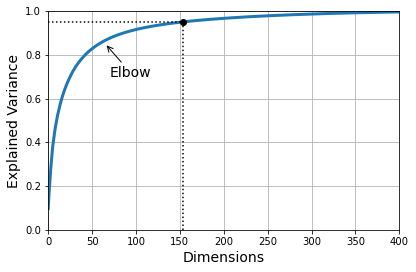

In [ ]:
# extra code – this cell generates and saves Figure 8–8

plt.figure(figsize=(6, 4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)
save_fig("explained_variance_plot")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       

In [ ]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': 465, 'pca__n_components': 23}


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

clf = make_pipeline(PCA(random_state=42), SGDClassifier())
param_grid = {"pca__n_components": np.arange(10, 80)}
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X_train[:1000], y_train[:1000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                       ('sgdclassifier', SGDClassifier())]),
             param_grid={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])})

In [ ]:
grid_search.best_params_

{'pca__n_components': 67}

## PCA cho Nén Dữ Liệu

In [ ]:
pca = PCA(0.95)
X_reduced = pca.fit_transform(X_train, y_train)

In [ ]:
X_recovered = pca.inverse_transform(X_reduced)

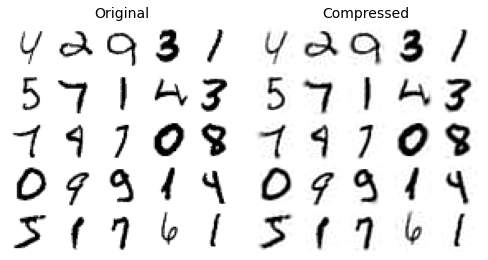

In [ ]:
# extra code – this cell generates and saves Figure 8–9

plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

save_fig("mnist_compression_plot")

## PCA ngẫu nhiên

In [ ]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

## PCA gia tăng

In [ ]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

**Sử dụng lớp memmap của NumPy – một ánh xạ bộ nhớ tới một mảng được lưu trữ trong một tệp nhị phân trên đĩa.**

Hãy tạo một thể hiện memmap, sao chép tập dữ liệu huấn luyện MNIST vào đó và gọi flush(), điều này đảm bảo rằng bất kỳ dữ liệu nào vẫn còn trong bộ nhớ đệm sẽ được lưu vào đĩa. Điều này thường được thực hiện bởi một chương trình đầu tiên:

In [ ]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train  # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()

Tiếp theo, một chương trình khác sẽ tải dữ liệu và sử dụng nó để đào tạo.

In [ ]:
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)

# Chiếu ngẫu nhiên

**Cảnh báo:** phần này sẽ sử dụng khoảng 2.5 GB RAM. Nếu máy tính của bạn hết bộ nhớ, chỉ cần giảm m và n.

In [ ]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, ε = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=ε)
d

7300

In [ ]:
# extra code – show the equation computed by johnson_lindenstrauss_min_dim
d = int(4 * np.log(m) / (ε ** 2 / 2 - ε ** 3 / 3))
d

7300

In [ ]:
n = 20_000
np.random.seed(42)
P = np.random.randn(d, n) / np.sqrt(d)  # std dev = square root of variance

X = np.random.randn(m, n)  # generate a fake dataset
X_reduced = X @ P.T

In [ ]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=ε, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)  # same result as above

Cảnh báo, ô dưới đây có thể mất vài phút để chạy.

In [ ]:
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

In [ ]:
# extra code – performance comparison between Gaussian and Sparse RP

from sklearn.random_projection import SparseRandomProjection

print("GaussianRandomProjection fit")
%timeit GaussianRandomProjection(random_state=42).fit(X)
print("SparseRandomProjection fit")
%timeit SparseRandomProjection(random_state=42).fit(X)

gaussian_rnd_proj = GaussianRandomProjection(random_state=42).fit(X)
sparse_rnd_proj = SparseRandomProjection(random_state=42).fit(X)
print("GaussianRandomProjection transform")
%timeit gaussian_rnd_proj.transform(X)
print("SparseRandomProjection transform")
%timeit sparse_rnd_proj.transform(X)

GaussianRandomProjection fit
4.05 s ± 327 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjection fit
3.85 s ± 647 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
GaussianRandomProjection transform
11.1 s ± 507 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjection transform
5.37 s ± 640 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# LLE

In [ ]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)

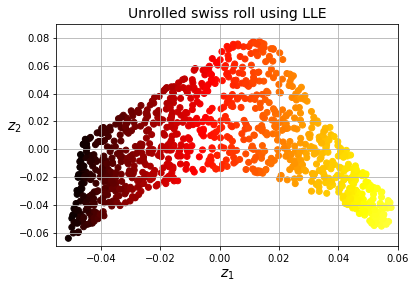

In [ ]:
# extra code – this cell generates and saves Figure 8–10

plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1],
            c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
plt.axis([-0.055, 0.060, -0.070, 0.090])
plt.grid(True)

save_fig("lle_unrolling_plot")
plt.title("Unrolled swiss roll using LLE")
plt.show()

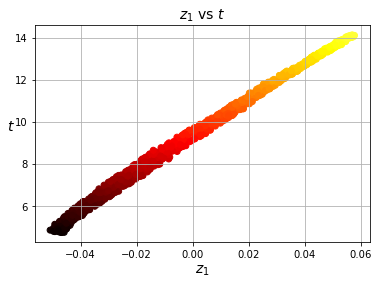

In [ ]:
# extra code – shows how well correlated z1 is to t: LLE worked fine
plt.title("$z_1$ vs $t$")
plt.scatter(X_unrolled[:, 0], t, c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$t$", rotation=0)
plt.grid(True)
plt.show()

Lưu ý: Tôi đã thêm `normalized_stress=False` bên dưới để tránh một cảnh báo về việc giá trị mặc định cho siêu tham số đó sẽ thay đổi trong tương lai. Vui lòng xem [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html) để biết thêm chi tiết.

In [ ]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, normalized_stress=False, random_state=42)
X_reduced_mds = mds.fit_transform(X_swiss)

In [ ]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X_swiss)

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
X_reduced_tsne = tsne.fit_transform(X_swiss)

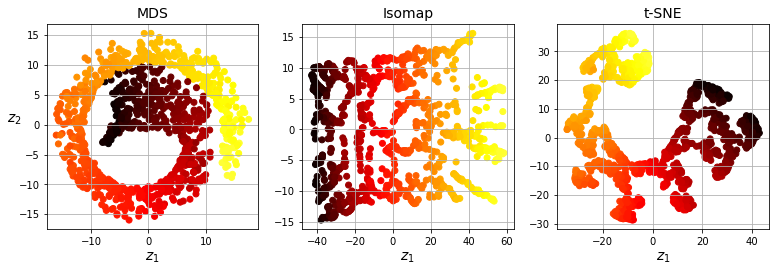

In [ ]:
# extra code – this cell generates and saves Figure 8–11

titles = ["MDS", "Isomap", "t-SNE"]

plt.figure(figsize=(11, 4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if subplot == 131:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid(True)

save_fig("other_dim_reduction_plot")
plt.show()

# Tài liệu bổ sung – Kernel PCA

In [ ]:
from sklearn.decomposition import KernelPCA

rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.04, random_state=42)
X_reduced = rbf_pca.fit_transform(X_swiss)

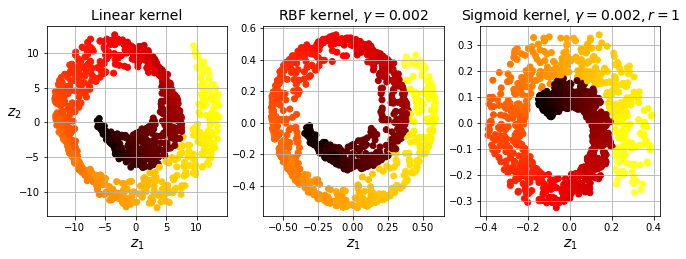

In [ ]:
lin_pca = KernelPCA(kernel="linear")
rbf_pca = KernelPCA(kernel="rbf", gamma=0.002)
sig_pca = KernelPCA(kernel="sigmoid", gamma=0.002, coef0=1)

kernel_pcas = ((lin_pca, "Linear kernel"),
               (rbf_pca, rf"RBF kernel, $\gamma={rbf_pca.gamma}$"),
               (sig_pca, rf"Sigmoid kernel, $\gamma={sig_pca.gamma}, r={sig_pca.coef0}$"))

plt.figure(figsize=(11, 3.5))
for idx, (kpca, title) in enumerate(kernel_pcas):
    kpca.n_components = 2
    kpca.random_state = 42
    X_reduced = kpca.fit_transform(X_swiss)

    plt.subplot(1, 3, idx + 1)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if idx == 0:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid()

plt.show()

# Bài tập

<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 1: ### 🧠 Phân tích & Lập luận (Chain of Thought)</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">Để giải quyết yêu cầu về bài tập **Chương 8: Giảm chiều dữ liệu (Dimensionality Reduction)**, tôi thực hiện phân tích dựa trên các tài liệu nguồn có sẵn trong hệ thống:</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 2: ---</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">### Danh sách 10 bài tập Chương 8</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 3: ---</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">### PHẦN 1: Chi tiết bài tập và lời giải lý thuyết (Từ Câu 1 đến Câu 8)</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 4: #### **Câu 2: Lời nguyền của số chiều là gì?**
*   **Lời giải chi tiết**:
    *   **Lời nguyền của số chiều (The curse of dimensionality)** đề cập đến thực tế là nhiều vấn đề không tồn tại trong không gian chiều thấp lại nảy sinh trong không gian chiều cao [cite: 672]. 
    *   Trong học máy, một biểu hiện phổ biến là thực tế **các vectơ chiều cao được lấy mẫu ngẫu nhiên thường rất cách xa nhau** [cite: 672]. Điều này làm cho dữ liệu trong không gian nhiều chiều trở nên cực kỳ thưa thớt, **làm tăng mạnh nguy cơ quá khớp (overfitting)** và khiến việc xác định các mẫu/ranh giới quyết định trở nên rất khó khăn nếu không có một lượng lớn dữ liệu huấn luyện khổng lồ hỗ trợ [cite: 653, 672].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">#### **Câu 3: Một khi chiều của tập dữ liệu đã được giảm, có thể đảo ngược thao tác không? Nếu có, bằng cách nào? Nếu không, tại sao?**
*   **Lời giải chi tiết**:
    *   Khi chiều của một tập dữ liệu đã được giảm, **hầu như luôn là không thể đảo ngược hoàn toàn hoạt động** (tức là khôi phục 100% dữ liệu gốc ban đầu) vì một phần thông tin hữu ích đã bị loại bỏ và mất đi vĩnh viễn trong quá trình giảm chiều [cite: 672].
    *   Tuy nhiên, một số thuật toán (chẳng hạn như **PCA**) có một **quy trình biến đổi ngược đơn giản (Inverse PCA)** cho phép chiếu dữ liệu đã giảm trở lại không gian ban đầu để tái tạo lại một tập dữ liệu tương đối giống với bản gốc [cite: 664, 672]. Đối với các thuật toán dựa trên học đa tạp phi tuyến khác (chẳng hạn như **t-SNE**), việc biến đổi ngược này là hoàn toàn bất khả thi [cite: 672].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 5: #### **Câu 5: Giả sử bạn thực hiện PCA trên một tập dữ liệu 1.000 chiều, đặt tỷ lệ phương sai giải thích là 95%. Tập dữ liệu kết quả sẽ có bao nhiêu chiều?**
*   **Lời giải chi tiết**:
    *   Đây là một **câu hỏi mẹo**: số lượng chiều thực tế hoàn toàn **phụ thuộc vào tập dữ liệu** cụ thể của bạn [cite: 78]. Hãy xem xét hai ví dụ cực đoan:
        *   *Ví dụ 1*: Nếu tập dữ liệu bao gồm các điểm gần như **thẳng hàng hoàn hảo** trong không gian, PCA có thể giảm tập dữ liệu xuống **chỉ còn đúng 1 chiều** duy nhất mà vẫn giữ được >95% phương sai giải thích [cite: 78].
        *   *Ví dụ 2*: Nếu tập dữ liệu bao gồm các điểm **hoàn toàn ngẫu nhiên** và phân tán đều khắp 1.000 chiều, bạn sẽ cần khoảng **950 chiều** để giữ lại 95% phương sai giải thích [cite: 78].
    *   Vì vậy, câu trả lời có thể là **bất kỳ số nào nằm trong khoảng từ 1 đến 950** [cite: 78]. Để ước tính số chiều thực tế, việc vẽ đồ thị phương sai giải thích tích lũy theo số chiều là phương pháp trực quan giúp bạn nhận diện chiều nội tại (intrinsic dimensionality) của tập dữ liệu [cite: 78].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">#### **Câu 6: Trong những trường hợp nào bạn sẽ sử dụng PCA thông thường, PCA tăng dần, PCA ngẫu nhiên, hoặc phép chiếu ngẫu nhiên?**
*   **Lời giải chi tiết**:
    *   **PCA thông thường (Regular PCA)**: Là mặc định, nên sử dụng khi tập dữ liệu **nằm gọn trong bộ nhớ RAM** của máy tính [cite: 672].
    *   **PCA tăng dần (Incremental PCA)**: Hữu ích cho các **tập dữ liệu lớn không nằm gọn trong bộ nhớ**, cho phép bạn tải dữ liệu và huấn luyện theo từng lô nhỏ (mini-batches) [cite: 672]. Nó cũng đặc biệt thích hợp cho các **tác vụ trực tuyến (online tasks)**, nơi bạn phải xử lý giảm chiều ngay lập tức mỗi khi có một trường hợp dữ liệu mới xuất hiện [cite: 672].
    *   **PCA ngẫu nhiên (Randomized PCA)**: Hữu ích khi bạn muốn **giảm đáng kể số chiều** dữ liệu (xuống một số chiều \\(d\\) nhỏ hơn nhiều so với số chiều gốc \\(n\\)) và dữ liệu của bạn nằm gọn trong RAM [cite: 672]. Thuật toán này sử dụng một xấp xỉ ngẫu nhiên để tìm nhanh các thành phần chính đầu tiên nên **nhanh hơn nhiều so với PCA thông thường** [cite: 672].
    *   **Phép chiếu ngẫu nhiên (Random Projection)**: Thích hợp cho các tập dữ liệu có **chiều dữ liệu siêu cao** (ví dụ: hàng trăm nghìn hoặc hàng triệu chiều) [cite: 672]. Thuật toán này giảm chiều cực kỳ nhanh, tối ưu hóa bộ nhớ hiệu quả và rất mạnh mẽ nhờ bảo toàn tốt khoảng cách giữa các điểm dữ liệu [cite: 666, 672].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 6: #### **Câu 8: Có ý nghĩa gì khi nối chuỗi hai thuật toán giảm chiều khác nhau không?**
*   **Lời giải chi tiết**:
    *   **Hoàn toàn có ý nghĩa** [cite: 78]. Một quy trình thiết kế đường ống dữ liệu vô cùng phổ biến là **sử dụng PCA hoặc Phép chiếu ngẫu nhiên** để nhanh chóng loại bỏ một số lượng khổng lồ các chiều dữ liệu vô dụng/nhiễu lúc đầu [cite: 78].
    *   Sau đó, bạn tiếp tục áp dụng một thuật toán giảm chiều phi tuyến phức tạp nhưng chạy rất chậm khác (như **LLE hoặc t-SNE**) trên tập dữ liệu đã nén này [cite: 78]. Cách tiếp cận hai bước này sẽ mang lại hiệu suất chất lượng tương đương như khi bạn chỉ sử dụng thuật toán phi tuyến trực tiếp ngay từ đầu, nhưng giúp **tiết kiệm một khoảng thời gian tính toán khổng lồ** [cite: 78].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">---
### 🌳 Sơ đồ Phân nhánh Lập luận (Tree of Thought)</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 7: ```
                                      [Tập dữ liệu MNIST (70,000 mẫu)] [cite: 100]
                                                     |
                +------------------------------------+------------------------------------+
                |                                                                         |
      [BÀI 9: Đánh giá PCA] [cite: 102]                                        [BÀI 10: Trực quan hóa 2D] [cite: 107]
                |                                                                         |
      +---------+---------+                                                     +---------+---------+
      |                   |                                                     |                   |
 [Random Forest]    [SGDClassifier] [cite: 101, 105]                         [t-SNE (2D)]       [Các thuật toán khác] [cite: 108, 114]
      |                   |                                                     |                   |
- Không PCA: 38.4s   - Không PCA: 2m35s                                   - Thời gian: 29.4s  - PCA: 157ms (Chồng lấn mạnh) [cite: 108, 114]
  (Acc: 97.05%)       (Acc: 87.4%) [cite: 101, 102, 105]                   (Tách cụm rất đẹp   - LLE: 8.86s (Rất tệ) [cite: 114]
- Có PCA: 1m28s      - Có PCA: 27.9s                                        nhưng chồng lấn    - MDS: 12m12s (Rất tệ) [cite: 116]
  (Acc: 94.81%)       (Acc: 89.59%) [cite: 103, 104, 106]                   3 vs 5, 4 vs 9) [cite: 109]
  👉 CHẬM ĐI 2 LẦN!    👉 NHANH GẤP 5 LẦN! [cite: 103, 106]
```</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">---</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 8: #### **Bài 9: Đánh giá tác động của PCA đối với Rừng ngẫu nhiên và SGDClassifier**</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">##### **1. Phân tích kết quả thực nghiệm từ tài liệu gốc**
*   **Mô hình Rừng ngẫu nhiên (Random Forest)**:
    *   Khi huấn luyện trên dữ liệu gốc (784 chiều), mô hình mất khoảng **38.4 giây** và đạt độ chính xác **97.05%** [cite: 101, 102].
    *   Sau khi dùng PCA để giữ lại 95% phương sai (giảm xuống còn 154 chiều) [cite: 92, 102], thời gian huấn luyện tăng lên đáng kể, mất **1 phút 28 giây** (chậm hơn khoảng **2 lần**) và độ chính xác bị giảm mạnh xuống còn **94.81%** [cite: 103, 104].
    *   **Giải thích nguyên nhân**: Giảm chiều dữ liệu không phải lúc nào cũng giúp tăng tốc độ huấn luyện [cite: 103]. Ảnh MNIST gốc rất thưa (sparse) vì hầu hết các pixel nền có giá trị bằng 0 [cite: 413]. Khi áp dụng PCA, các thành phần chính mới thu được là các tổ hợp tuyến tính của toàn bộ pixel gốc, biến dữ liệu thưa thành dữ liệu dày đặc (dense) không còn các giá trị 0 [cite: 413]. Thuật toán xây dựng cây quyết định của Rừng ngẫu nhiên phải duyệt qua các giá trị liên tục phức tạp hơn rất nhiều để tìm điểm chia tối ưu, dẫn đến việc huấn luyện bị chậm đi đáng kể [cite: 103].
*   **Mô hình SGDClassifier**:
    *   Trên dữ liệu gốc, `SGDClassifier` mất tới **2 phút 35 giây** để huấn luyện và chỉ đạt độ chính xác **87.4%** [cite: 105].
    *   Khi áp dụng trên dữ liệu đã giảm chiều bằng PCA, thời gian huấn luyện giảm cực nhanh chỉ còn **27.9 giây** (nhanh hơn **5 lần**) và độ chính xác được cải thiện đáng kể lên **89.59%** [cite: 106].
    *   **Giải thích nguyên nhân**: Vì `SGDClassifier` là một mô hình tuyến tính, việc giảm số lượng đặc trưng đầu vào từ 784 xuống 154 giúp giảm số lượng phép tính nhân ma trận một cách trực tiếp [cite: 34, 413], giúp mô hình hội tụ nhanh hơn nhiều và đồng thời PCA đã lọc bớt các nhiễu ngẫu nhiên giúp tăng nhẹ độ chính xác [cite: 99, 106].</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 9: # 1. Tải tập dữ liệu MNIST [cite: 100]
mnist = fetch_openml('mnist_784', as_frame=False, parser="auto") [cite: 92]
X_train, y_train = mnist.data[:60000], mnist.target[:60000] [cite: 92]
X_test, y_test = mnist.data[60000:], mnist.target[60000:] [cite: 101]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># ========================================================
# THỬ NGHIỆM 1: RANDOM FOREST
# ========================================================
print("--- 1. Rừng ngẫu nhiên trên dữ liệu gốc ---")
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42) [cite: 101]
t0 = time.time()
rnd_clf.fit(X_train, y_train) [cite: 101]
t1 = time.time()
y_pred = rnd_clf.predict(X_test) [cite: 102]
print(f"Thời gian huấn luyện: {t1 - t0:.2f}s")
print(f"Độ chính xác: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 10: print("--- 2. Rừng ngẫu nhiên trên dữ liệu đã giảm chiều ---")
rnd_clf_pca = RandomForestClassifier(n_estimators=100, random_state=42) [cite: 103]
t0 = time.time()
rnd_clf_pca.fit(X_train_reduced, y_train) [cite: 103]
t1 = time.time()
y_pred_pca = rnd_clf_pca.predict(X_test_reduced) [cite: 104]
print(f"Thời gian huấn luyện: {t1 - t0:.2f}s")
print(f"Độ chính xác: {accuracy_score(y_test, y_pred_pca) * 100:.2f}%\n")</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># ========================================================
# THỬ NGHIỆM 2: SGDCLASSIFIER [cite: 105]
# ========================================================
print("--- 3. SGDClassifier trên dữ liệu gốc ---")
sgd_clf = SGDClassifier(random_state=42)
t0 = time.time()
sgd_clf.fit(X_train, y_train) [cite: 105]
t1 = time.time()
y_pred_sgd = sgd_clf.predict(X_test) [cite: 105]
print(f"Thời gian huấn luyện: {t1 - t0:.2f}s")
print(f"Độ chính xác: {accuracy_score(y_test, y_pred_sgd) * 100:.2f}%\n")</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 11: ---</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">#### **Bài 10: Trực quan hóa tập dữ liệu MNIST bằng t-SNE và So sánh thuật toán**</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 12: ##### **2. Đoạn mã Python tối ưu**
Mã nguồn dưới đây bao gồm cả hàm bổ trợ nâng cao `plot_digits` để vẽ các hình ảnh thu nhỏ trực tiếp lên biểu đồ thay thế các chấm màu đơn điệu, lấy cảm hứng từ tài liệu thực hành Scikit-Learn [cite: 112].</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">```python
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImport, OffsetImage [cite: 112]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 13: # 2. Áp dụng t-SNE giảm xuống 2 chiều [cite: 108]
tsne = TSNE(n_components=2, init="random", learning_rate="auto", random_state=42) [cite: 108]
print("Đang huấn luyện t-SNE trên 5.000 mẫu...")
X_reduced = tsne.fit_transform(X_sample) [cite: 108]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># 3. Hàm vẽ biểu đồ nâng cao hiển thị ảnh chữ số thu nhỏ [cite: 112]
def plot_digits(X, y, images=None, figsize=(13, 10), min_distance=0.04): [cite: 112]
    # Chuẩn hóa dữ liệu về khoảng để hiển thị đều trên đồ thị [cite: 112]
    X_normalized = MinMaxScaler().fit_transform(X) [cite: 112]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 14: # Sử dụng colormap jet để tạo 10 màu cho 10 chữ số [cite: 109, 112]
    cmap = plt.cm.jet [cite: 112]
    digits = np.unique(y) [cite: 112]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">for digit in digits:
        # Vẽ các điểm chấm đại diện cho từng lớp trước [cite: 112]
        plt.scatter(X_normalized[y == digit, 0], X_normalized[y == digit, 1], 
                    c=[cmap(float(digit) / 9)], alpha=0.5) [cite: 112]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 15: # Thiết lập cơ chế vẽ hình ảnh thu nhỏ nếu có tham số images [cite: 112]
    if images is not None:
        shown_images = np.array([[10., 10.]]) # Tránh vẽ các ảnh đè lên nhau [cite: 112]
        for i in range(len(X)):
            # Tính toán khoảng cách tối thiểu giữa ảnh hiện tại và các ảnh đã vẽ [cite: 112]
            dist = np.sum((X_normalized[i] - shown_images) ** 2, axis=1) [cite: 112]
            if np.min(dist) < min_distance:
                continue # Nếu quá gần thì bỏ qua không vẽ để tránh lộn xộn [cite: 112]</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;">shown_images = np.r_[shown_images, [X_normalized[i]]] [cite: 112]</p>
  </div>
</div>
<div style="border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; margin-bottom: 20px; background-color: #fcfcfc;">
  <p style="font-weight: 600; color: #1a73e8; margin-top: 0;">Câu 16: plt.show()</p>
  <div style="margin-top: 10px; padding-left: 10px; border-left: 3px solid #1a73e8;">
    <p style="margin: 0; color: #555;">💡 <strong>Gợi ý:</strong></p>
    <p style="margin: 5px 0 0 0;"># 4. Thực thi vẽ biểu đồ phân tán thông thường [cite: 109]
print("--- Đang trực quan hóa biểu đồ phân tán t-SNE tiêu chuẩn ---")
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_sample.astype(np.int8), cmap="jet", alpha=0.5) [cite: 109]
plt.axis('off') [cite: 109]
plt.colorbar() [cite: 109]
plt.show()</p>
  </div>
</div>
